# Moodsic — PERCEIVE E2E Flow Demo

Use this notebook to quickly experiment with the PERCEIVE stage.

Flow:
- Run Setup and Adapters.
- Run Helpers.
- In the Experiment cell, edit only `IMG_PATH`, then run it to see: preview, overlay with face box, and fused valence/arousal.

Notes:
- If adapters/weights are unavailable, the code degrades gracefully.
- Inputs must be 3-channel BGR images (OpenCV).


In [23]:
# Setup: ensure repo root on sys.path for imports from models/utils
import os, sys
from pathlib import Path

repo_root = Path.cwd()
# If notebook is opened from notebooks/, add parent as repo root
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import math
import random
import numpy as np
import matplotlib.pyplot as plt

try:
    import cv2
except Exception as e:
    raise RuntimeError(f"OpenCV (cv2) is required to run this demo: {e}")

from utils.runtime_driver import perceive_once

print("Repo root:", repo_root)


Repo root: /Users/yuen@backbase.com/Downloads/School/Emorec/emo-rec


In [25]:
import clip
import torch

# Load adapters (best-effort) — tries both scene and face paths
scene_adapter = None
face_processor = None
face_adapter = None


# Scene adapter: CLIP ViT (using direct OpenAI CLIP library)
try:
    from models.scene.clip_vit_scene_adapter import SceneCLIPAdapter
    
    # Load CLIP model directly first
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
    
    scene_adapter = SceneCLIPAdapter(
        pretrained_model=clip_model,  # Pass the loaded model
        preprocess=clip_preprocess,   # Pass the preprocessor
        dropout_rate=0.3,
        device=device,
        tta=3,
    )
    print('SceneCLIPAdapter: OK')
except Exception as e:
    print(f'SceneCLIPAdapter unavailable (clip/weights/device): {e}')

# Face processor: MediaPipe-based cropper (optional)
try:
    from utils.emonet_single_face_processor import EmoNetSingleFaceProcessor

    face_processor = EmoNetSingleFaceProcessor(
        min_detection_confidence=0.5, padding_ratio=0.2
    )
    print("Face processor available:", getattr(face_processor, "available", False))
except Exception as e:
    print(f"Face processor unavailable (mediapipe missing?): {e}")

# Face adapter: EmoNet (optional weights from models/emonet/pretrained)
try:
    from models.face.emonet_adapter import EmoNetAdapter

    face_adapter = EmoNetAdapter(
        ckpt_dir="models/emonet/pretrained",
        n_classes=8,
        device="auto",
        tta=3,
        calibration_checkpoint=None,
    )
    print("EmoNetAdapter: OK")
except Exception as e:
    print(f"EmoNetAdapter unavailable (torch/weights/device): {e}")


  ✅ Using pre-loaded CLIP model
SceneCLIPAdapter: OK
Face processor available: True


I0000 00:00:1758894399.647220  265721 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1758894399.785014  755145 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


EmoNetAdapter: OK


In [26]:
#Helpers
def load_image(path: str):
    p = Path(path)
    if not p.exists():
        alt = repo_root / path
        if alt.exists():
            p = alt
        else:
            matches = list(repo_root.rglob(p.name)) if p.name else []
            if matches:
                p = matches[0]
                print(f"[info] image not found at given path; using first match: {p}")
            else:
                print(f"[skip] image not found: {path}")
                return None
    img = cv2.imread(str(p))
    if img is None:
        print(f"[skip] failed to read image: {p}")
        return None
    if img.ndim != 3 or img.shape[2] != 3:
        print("[skip] expecting a 3-channel BGR image")
        return None
    return img

def print_fusion_result(res, label: str = ""):
    if not res:
        print(f"{label} — no result")
        return

    def fmt_pred(p):
        if p is None:
            return "None"
        return (
            f"V={p.valence:.3f}, A={p.arousal:.3f}, "
            f"varV={(p.var_valence if p.var_valence is not None else float('nan')):.4f}, "
            f"varA={(p.var_arousal if p.var_arousal is not None else float('nan')):.4f}, "
            f"valid={p.valid}"
        )

    scene_s = fmt_pred(res.scene)
    face_s = fmt_pred(res.face)
    fused_s = fmt_pred(res.fused)
    print(f"=== {label} ===")
    print(f"SCENE: {scene_s}")
    print(f"FACE : {face_s}")
    print(f"FUSED: {fused_s}")
    if getattr(res, "face_bbox", None) is not None:
        print(f"face_bbox={res.face_bbox}, face_score={res.face_score:.3f}")

SAMPLE_IMAGES = {
    "with_face": (
        "data/Run_2/Accepting adults meeting/"
        "videoblocks-diverse-group-of-multinational-business-people-taking-part-in-"
        "corporate-meeting-bored-african-american-man-yawning-while-other-members-"
        "of-seminar-attentively-listening-speech-and-writing-notes_"
        "rsz1toto3e_thumbnail-1080_01.png"
    ),
    "no_face": (
        "data/Run_2/Affectionate retiree competition/"
        "Elderly-group-in-museum-1200x800.jpg"
    ),
}

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def get_random_dataset_image(seed=None):
    run_dirs = [repo_root / "data" / "Run_1", repo_root / "data" / "Run_2"]
    candidates = []
    for directory in run_dirs:
        if not directory.exists():
            continue
        candidates.extend(
            path for path in directory.rglob("*")
            if path.is_file() and path.suffix.lower() in IMAGE_EXTS
        )
    if not candidates:
        raise SystemExit("No images found in data/Run_1 or data/Run_2")
    rng = random.Random(seed)
    return rng.choice(candidates)

# Try to import overlay helper
try:
    from utils.fusion_overlay import draw_fusion_overlay
except Exception as overlay_exc:
    draw_fusion_overlay = None
    OVERLAY_IMPORT_ERROR = overlay_exc
else:
    OVERLAY_IMPORT_ERROR = None

def run_experiment(img_path: str, *, label: str = "PERCEIVE — single image"):
    """Run PERCEIVE once and render preview plus overlay."""
    img = load_image(img_path)
    if img is None:
        raise SystemExit("Input image missing; update IMG_PATH and rerun.")

    res = perceive_once(
        img,
        scene_predictor=scene_adapter,
        face_processor=face_processor,
        face_expert=face_adapter,
        scene_tta=3,
        face_tta=3,
    )
    print_fusion_result(res, label=label)

    overlay = None
    if draw_fusion_overlay is not None:
        try:
            overlay = draw_fusion_overlay(img, res)
        except Exception as exc:
            print(f"[info] overlay unavailable: {exc}")
    elif OVERLAY_IMPORT_ERROR is not None:
        print(f"[info] overlay helper unavailable: {OVERLAY_IMPORT_ERROR}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Preview")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    if overlay is not None:
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.title("Overlay")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Overlay (unavailable; showing input)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def process_video(video_path: str, frame_interval: int = 25, show_progress: bool = True):
    """
    Process video and return emotion predictions for sampled frames.
    
    Args:
        video_path: Path to video file
        frame_interval: Process every Nth frame (default 25 = 1 sec at 25fps)
        show_progress: Print progress updates
    
    Returns:
        List of dicts with timestamp, frame_idx, valence, arousal, result object
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    results = []
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if frame_count % frame_interval == 0:
            timestamp = frame_count / fps
            
            res = perceive_once(
                frame,
                scene_predictor=scene_adapter,
                face_processor=face_processor,
                face_expert=face_adapter,
                scene_tta=3,
                face_tta=3,
            )
            
            valence = res.fused.valence if res.fused and res.fused.valid else None
            arousal = res.fused.arousal if res.fused and res.fused.valid else None
            
            results.append({
                'timestamp': timestamp,
                'frame_idx': frame_count,
                'valence': valence,
                'arousal': arousal,
                'has_face': res.face is not None and res.face.valid,
                'frame': frame,
                'result': res
            })
            
            if show_progress:
                print(f"Processed frame {frame_count}/{total_frames} (t={timestamp:.1f}s)")
        
        frame_count += 1
    
    cap.release()
    return results

def run_video_experiment(video_path: str, frame_interval: int = 25, 
                         show_frames: int = 3, label: str = "PERCEIVE — video"):
    """Run PERCEIVE on video and display results with overlays."""
    print(f"{label}")
    print(f"Processing: {video_path}")
    print(f"Frame interval: {frame_interval}")
    print("-" * 60)
    
    results = process_video(video_path, frame_interval=frame_interval, show_progress=True)
    
    print(f"\nProcessed {len(results)} frames")
    print("-" * 60)
    
    # Show detailed results for first few frames
    for i, r in enumerate(results[:show_frames]):
        print_fusion_result(r['result'], f"Frame {r['frame_idx']} (t={r['timestamp']:.1f}s)")
    
    # Display frames with overlays
    n_show = min(show_frames, len(results))
    fig, axes = plt.subplots(n_show, 2, figsize=(12, 5 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)
    
    for i, r in enumerate(results[:n_show]):
        frame = r['frame']
        res = r['result']
        
        # Preview
        axes[i, 0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"Frame {r['frame_idx']} (t={r['timestamp']:.1f}s)")
        axes[i, 0].axis("off")
        
        # Overlay
        overlay = None
        if draw_fusion_overlay is not None:
            try:
                overlay = draw_fusion_overlay(frame, res)
            except Exception as exc:
                print(f"[info] overlay unavailable for frame {i}: {exc}")
        
        if overlay is not None:
            axes[i, 1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
            axes[i, 1].set_title(f"Overlay (V={r['valence']:.2f}, A={r['arousal']:.2f})")
        else:
            axes[i, 1].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            axes[i, 1].set_title("Overlay (unavailable)")
        axes[i, 1].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    return results


## EXPERIMENTATION

Quick instructions to run single-image experiments:
- Run the three setup cells above: Setup, Adapters, Helpers.
- Update `SAMPLE_IMAGES` in the Helpers cell if you want to add or rename presets.
- In the Experiment cell, pick a `SAMPLE_KEY` (or set it to `None` and provide `CUSTOM_IMG_PATH`).
- Run that cell; it prints results and displays Preview and Overlay.

What you can change:
- `SAMPLE_KEY` / `CUSTOM_IMG_PATH`: choose a preset, use `"random"`, or supply an absolute/repo-relative path.
- Fusion settings: edit `run_experiment(...)` (scene/face TTA, weighting kwargs passed to `perceive_once`).
- Guardrails: pass `face_score_threshold`, `face_max_sigma`, or `brightness_threshold` into `perceive_once`.
- `RANDOM_SEED`: set to an int to make the random sample reproducible.

Outputs and overlay:
- Console: SCENE, FACE, FUSED V/A with variances (`varV`, `varA`); lower variance = higher confidence.
- Overlay: draws face bbox (if detected) and writes fused/face/scene numbers on the image (right panel).

Dependencies and fallbacks:
- OpenCV (`cv2`) is required for IO and plotting.
- Scene adapter uses CLIP (transformers + pretrained weights). If unavailable, scene may be `None`.
- Face path needs MediaPipe for detection; EmoNet weights are optional (random init runs but is not meaningful).
- If a path is unavailable or invalid for a frame, fusion degrades to the other path.

Troubleshooting:
- If you see `[skip] image not found/failed to read`, fix the path (absolute or repo-relative).
- If no face is detected, overlay shows no box and FACE may be unavailable; try another image.
- For dark/occluded frames, consider enabling face guardrails by tweaking `run_experiment(...)` kwargs.



I0000 00:00:1758894418.718232  265721 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1758894418.721219  755354 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


=== PERCEIVE — random (AP22067807875799.jpg, seed=20) ===
SCENE: V=0.458, A=-0.602, varV=0.2308, varA=0.2803, valid=True
FACE : V=-0.478, A=0.091, varV=0.0395, varA=0.0352, valid=True
FUSED: V=-0.341, A=0.014, varV=0.0337, varA=0.0313, valid=True
face_bbox=(471, 222, 104, 103), face_score=0.052


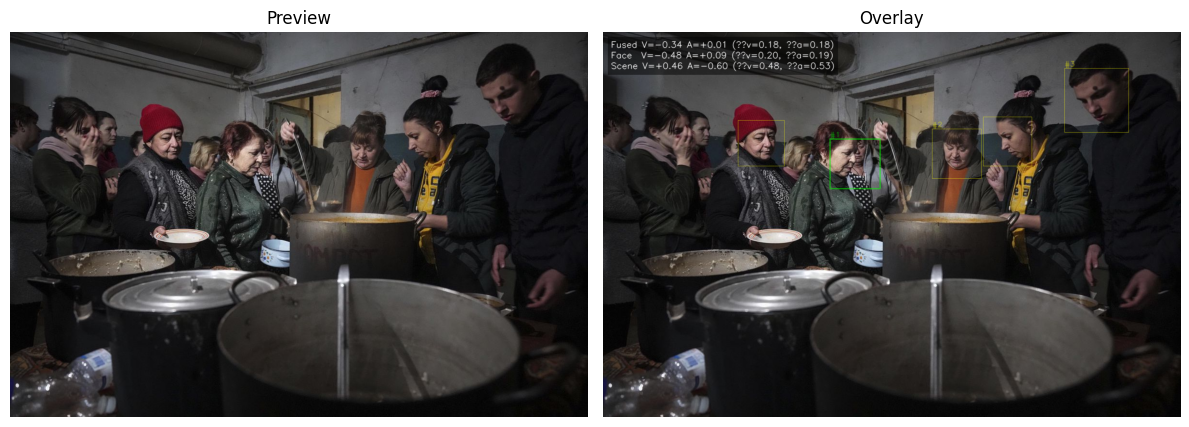

In [27]:
# Experiment:
# Choose a sample key or provide a custom path, then run this cell.

SAMPLE_KEY = "random"  # Options: with_face, no_face, with_face_far, random; set to None for custom path.
CUSTOM_IMG_PATH = (
    ""  # Fill with absolute or repo-relative path when SAMPLE_KEY is None.
)
RANDOM_SEED = 20  # Set to an int for reproducible random selection.

if SAMPLE_KEY is not None:
    key = SAMPLE_KEY.lower()
    valid = ", ".join(list(SAMPLE_IMAGES) + ["random"])
    if key not in SAMPLE_IMAGES and key != "random":
        raise SystemExit(f"Unknown SAMPLE_KEY {SAMPLE_KEY!r}. Valid options: {valid}")
    if key == "random":
        chosen = get_random_dataset_image(seed=RANDOM_SEED)
        IMG_PATH = str(chosen)
        if RANDOM_SEED is None:
            LABEL = f"PERCEIVE — random ({chosen.name})"
        else:
            LABEL = f"PERCEIVE — random ({chosen.name}, seed={RANDOM_SEED})"
    else:
        IMG_PATH = SAMPLE_IMAGES[key]
        LABEL = f"PERCEIVE — {key}"
else:
    if not CUSTOM_IMG_PATH:
        raise SystemExit("Set SAMPLE_KEY or CUSTOM_IMG_PATH before running.")
    IMG_PATH = CUSTOM_IMG_PATH
    LABEL = f"PERCEIVE — {IMG_PATH}"

run_experiment(IMG_PATH, label=LABEL)


PERCEIVE — video
Processing: /Users/yuen@backbase.com/Downloads/School/Emorec/VEATIC/videos/94.mp4
Frame interval: 100
------------------------------------------------------------
Processed frame 0/2064 (t=0.0s)
Processed frame 100/2064 (t=4.0s)
Processed frame 200/2064 (t=8.0s)
Processed frame 300/2064 (t=12.0s)
Processed frame 400/2064 (t=16.0s)
Processed frame 500/2064 (t=20.0s)
Processed frame 600/2064 (t=24.0s)
Processed frame 700/2064 (t=28.0s)
Processed frame 800/2064 (t=32.0s)
Processed frame 900/2064 (t=36.0s)
Processed frame 1000/2064 (t=40.0s)
Processed frame 1100/2064 (t=44.0s)
Processed frame 1200/2064 (t=48.0s)
Processed frame 1300/2064 (t=52.0s)
Processed frame 1400/2064 (t=56.0s)
Processed frame 1500/2064 (t=60.0s)
Processed frame 1600/2064 (t=64.0s)
Processed frame 1700/2064 (t=68.0s)
Processed frame 1800/2064 (t=72.0s)
Processed frame 1900/2064 (t=76.0s)
Processed frame 2000/2064 (t=80.0s)

Processed 21 frames
----------------------------------------------------------

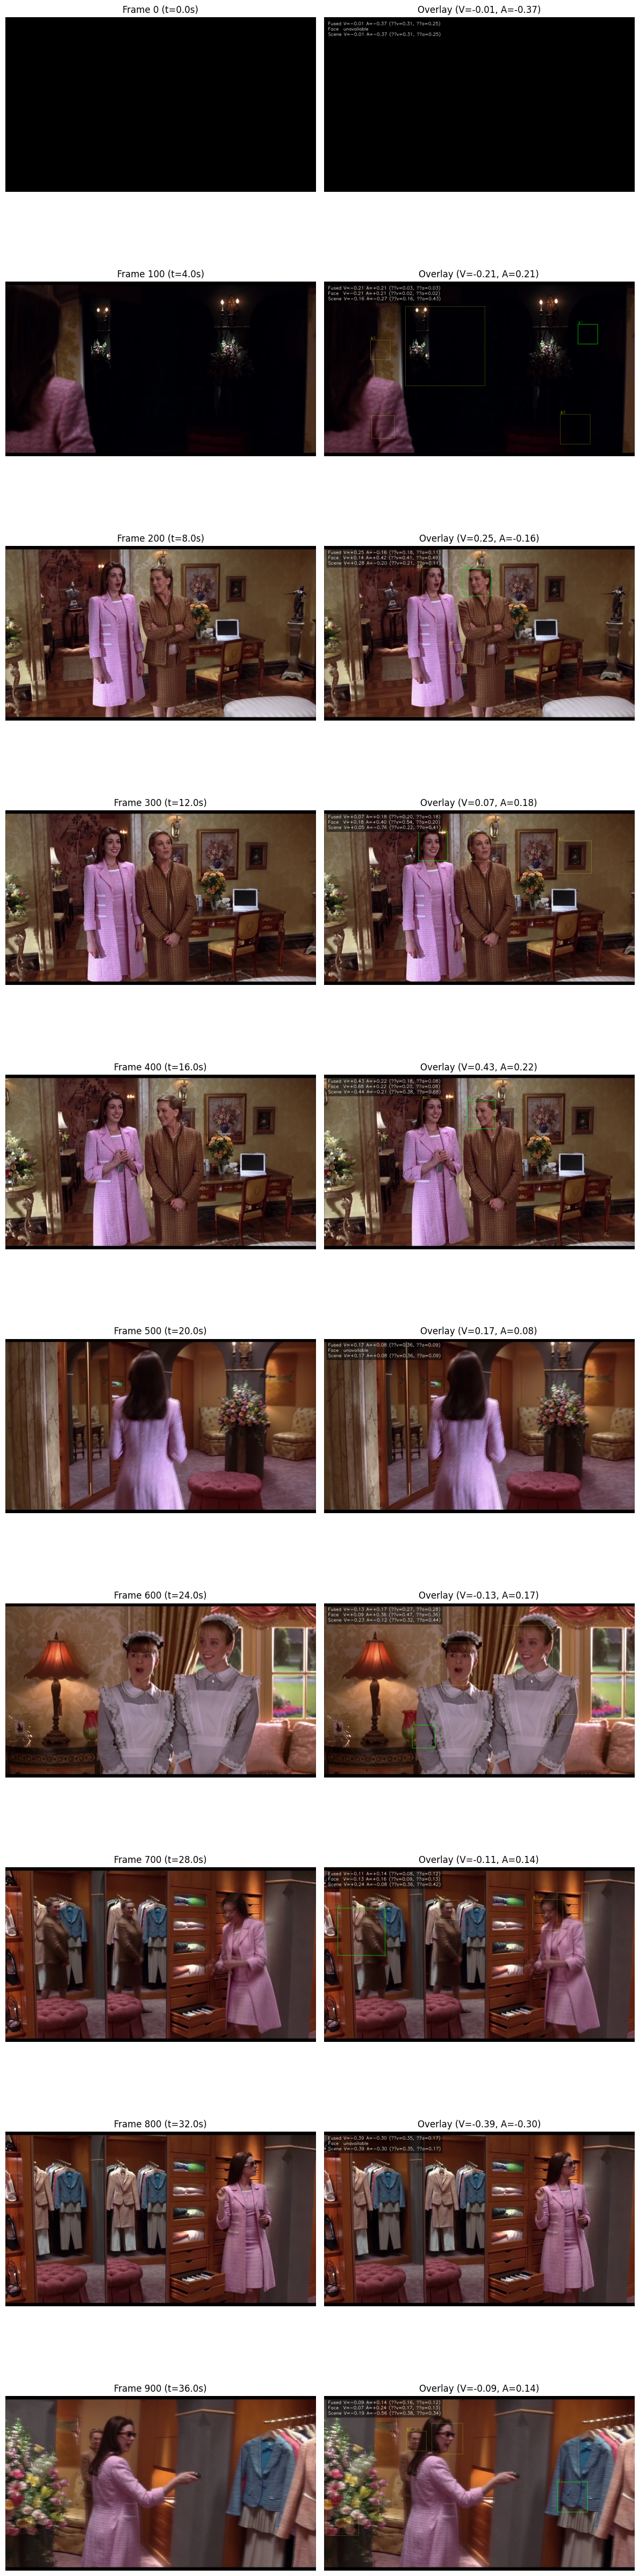

In [ ]:
VIDEO_PATH = "/Downloads/School/Emorec/VEATIC/videos/94.mp4"  # Update this path
FRAME_INTERVAL = 100  # Process every 25 frames (1 second at 25fps)
SHOW_FRAMES = 10  # Number of frames to display with overlays

video_results = run_video_experiment(
    VIDEO_PATH, 
    frame_interval=FRAME_INTERVAL,
    show_frames=SHOW_FRAMES,
    label="PERCEIVE — video"
)


In [ ]:
# CELL: Load Song Matcher (add after loading emotion models)

from utils.song_matcher import SongMatcher
from pathlib import Path

# Load DEAM songs from parquet file
SONGS_PARQUET = Path("/Downloads/School/Emorec/emo-rec/notebooks/deam/artifacts/deam_gmm/deam_songs.parquet")
ARTIFACTS_DIR = Path("/Downloads/School/Emorec/emo-rec/notebooks/deam/artifacts/deam_gmm")  # Directory with scaler.pkl and gmm.pkl

# Read parquet file
songs_df = pd.read_parquet(SONGS_PARQUET)

# Check and rename columns if needed
print(f"Original columns: {list(songs_df.columns)}")

# Map common DEAM column variations to expected names
column_mapping = {}
if 'valence_mean' in songs_df.columns and 'valence_ref' not in songs_df.columns:
    column_mapping['valence_mean'] = 'valence_ref'
if 'arousal_mean' in songs_df.columns and 'arousal_ref' not in songs_df.columns:
    column_mapping['arousal_mean'] = 'arousal_ref'
if 'gmm_cluster' in songs_df.columns and 'cluster' not in songs_df.columns:
    column_mapping['gmm_cluster'] = 'cluster'

if column_mapping:
    songs_df = songs_df.rename(columns=column_mapping)
    print(f"Renamed columns: {column_mapping}")

# Ensure song_id exists
if 'song_id' not in songs_df.columns:
    if 'id' in songs_df.columns:
        songs_df = songs_df.rename(columns={'id': 'song_id'})
    else:
        songs_df['song_id'] = songs_df.index.astype(str)
    print("Created/renamed song_id column")

# Verify required columns exist
required_cols = ['song_id', 'valence_ref', 'arousal_ref', 'cluster']
missing = [col for col in required_cols if col not in songs_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available: {list(songs_df.columns)}")

print(f"\nFinal columns: {list(songs_df.columns)}")

# Initialize song matcher with artifacts
song_matcher = SongMatcher.from_artifacts(
    songs_df=songs_df,
    artifacts_dir=ARTIFACTS_DIR,
    min_dwell_time=25.0,      # Stay on same song for at least 25 seconds
    recent_k=5,                # Remember last 5 songs to avoid repeats
    top2_threshold=0.55,       # If top cluster < 55%, consider top 2 clusters
    valence_col="valence_ref",
    arousal_col="arousal_ref",
    cluster_col="cluster"
)

print(f"\nLoaded {len(songs_df)} songs from {SONGS_PARQUET}")
print(f"Song matcher ready with GMM gating and dwell time enforcement")

# Test recommendation
test_match = song_matcher.recommend(v_ref=0.5, a_ref=0.5, now=0.0)
if test_match.song is not None:
    print(f"\nTest recommendation at V=0.5, A=0.5:")
    print(f"  Song ID: {test_match.song['song_id']}")
    if 'title' in test_match.song:
        print(f"  Title: {test_match.song['title']}")
    print(f"  Cluster: {test_match.song['cluster']}")


Original columns: ['song_id', 'valence_ref', 'arousal_ref', 'artist', 'song_title', 'genre', 'cluster', 'cluster_conf']

Final columns: ['song_id', 'valence_ref', 'arousal_ref', 'artist', 'song_title', 'genre', 'cluster', 'cluster_conf']

Loaded 1802 songs from /Users/yuen@backbase.com/Downloads/School/Emorec/emo-rec/notebooks/deam/artifacts/deam_gmm/deam_songs.parquet
Song matcher ready with GMM gating and dwell time enforcement

Test recommendation at V=0.5, A=0.5:
  Song ID: 397
  Cluster: 0


In [20]:
# CELL: Video Processing with Song Recommendations

def process_video_with_songs(video_path: str, frame_interval: int = 25, 
                              show_frames: int = 3):
    """
    Process video and recommend songs based on fused emotion predictions.
    """
    print(f"Processing: {video_path}")
    print(f"Frame interval: {frame_interval}")
    print("-" * 60)
    
    # Reset song matcher for new video
    song_matcher.reset()
    
    # Process video frames
    video_results = process_video(video_path, frame_interval=frame_interval, 
                                   show_progress=True)
    
    # Get song recommendations for each frame
    song_recommendations = []
    for r in video_results:
        if r['valence'] is not None and r['arousal'] is not None:
            match = song_matcher.recommend(
                v_ref=r['valence'],
                a_ref=r['arousal'],
                now=r['timestamp']
            )
            song_recommendations.append({
                'timestamp': r['timestamp'],
                'frame_idx': r['frame_idx'],
                'valence': r['valence'],
                'arousal': r['arousal'],
                'song_id': match.song['song_id'] if match.song is not None else None,
                'song_title': match.song.get('title', 'Unknown') if match.song is not None else None,
                'switch': match.switch
            })
        else:
            song_recommendations.append({
                'timestamp': r['timestamp'],
                'frame_idx': r['frame_idx'],
                'valence': None,
                'arousal': None,
                'song_id': None,
                'song_title': None,
                'switch': False
            })
    
    # Display results
    print(f"\nProcessed {len(video_results)} frames")
    print(f"Song switches: {sum(1 for s in song_recommendations if s['switch'])}")
    print("-" * 60)
    
    # Show detailed results for first few frames
    for i, (vr, sr) in enumerate(zip(video_results[:show_frames], 
                                      song_recommendations[:show_frames])):
        print_fusion_result(vr['result'], 
                           f"Frame {vr['frame_idx']} (t={vr['timestamp']:.1f}s)")
        print(f"  → Song: {sr['song_title']} (ID: {sr['song_id']}) "
              f"{'[SWITCH]' if sr['switch'] else ''}\n")
    
    return video_results, song_recommendations

In [ ]:
# CELL: Run Video Processing with Songs

VIDEO_PATH = "/Downloads/School/Emorec/VEATIC/videos/94.mp4"  # Update this
FRAME_INTERVAL = 25  # 1 second at 25fps

video_results, song_recs = process_video_with_songs(
    VIDEO_PATH, 
    frame_interval=FRAME_INTERVAL,
    show_frames=5
)

Processing: /Users/yuen@backbase.com/Downloads/School/Emorec/VEATIC/videos/94.mp4
Frame interval: 25
------------------------------------------------------------
Processed frame 0/2064 (t=0.0s)
Processed frame 25/2064 (t=1.0s)
Processed frame 50/2064 (t=2.0s)
Processed frame 75/2064 (t=3.0s)
Processed frame 100/2064 (t=4.0s)
Processed frame 125/2064 (t=5.0s)
Processed frame 150/2064 (t=6.0s)
Processed frame 175/2064 (t=7.0s)
Processed frame 200/2064 (t=8.0s)
Processed frame 225/2064 (t=9.0s)
Processed frame 250/2064 (t=10.0s)
Processed frame 275/2064 (t=11.0s)
Processed frame 300/2064 (t=12.0s)
Processed frame 325/2064 (t=13.0s)
Processed frame 350/2064 (t=14.0s)
Processed frame 375/2064 (t=15.0s)
Processed frame 400/2064 (t=16.0s)
Processed frame 425/2064 (t=17.0s)
Processed frame 450/2064 (t=18.0s)
Processed frame 475/2064 (t=19.0s)
Processed frame 500/2064 (t=20.0s)
Processed frame 525/2064 (t=21.0s)
Processed frame 550/2064 (t=22.0s)
Processed frame 575/2064 (t=23.0s)
Processed fra

# v2

In [29]:
#V2 CELL: Load Song Matcher (add after loading emotion models)

from utils.song_matcher import SongMatcher
from pathlib import Path

# Load DEAM songs from parquet file
SONGS_PARQUET = Path("/Users/yuen@backbase.com/Downloads/School/Emorec/emo-rec/notebooks/deam/artifacts/deam_gmm/deam_songs.parquet")
ARTIFACTS_DIR = Path("/Users/yuen@backbase.com/Downloads/School/Emorec/emo-rec/notebooks/deam/artifacts/deam_gmm")  # Directory with scaler.pkl and gmm.pkl

# Read parquet file
songs_df = pd.read_parquet(SONGS_PARQUET)

# Check and rename columns if needed
print(f"Original columns: {list(songs_df.columns)}")

# Map common DEAM column variations to expected names
column_mapping = {}
if 'valence_mean' in songs_df.columns and 'valence_ref' not in songs_df.columns:
    column_mapping['valence_mean'] = 'valence_ref'
if 'arousal_mean' in songs_df.columns and 'arousal_ref' not in songs_df.columns:
    column_mapping['arousal_mean'] = 'arousal_ref'
if 'gmm_cluster' in songs_df.columns and 'cluster' not in songs_df.columns:
    column_mapping['gmm_cluster'] = 'cluster'

if column_mapping:
    songs_df = songs_df.rename(columns=column_mapping)
    print(f"Renamed columns: {column_mapping}")

# Ensure song_id exists
if 'song_id' not in songs_df.columns:
    if 'id' in songs_df.columns:
        songs_df = songs_df.rename(columns={'id': 'song_id'})
    else:
        songs_df['song_id'] = songs_df.index.astype(str)
    print("Created/renamed song_id column")

# Verify required columns exist
required_cols = ['song_id', 'valence_ref', 'arousal_ref', 'cluster']
missing = [col for col in required_cols if col not in songs_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available: {list(songs_df.columns)}")

print(f"\nFinal columns: {list(songs_df.columns)}")

# Initialize song matcher with artifacts
song_matcher = SongMatcher.from_artifacts(
    songs_df=songs_df,
    artifacts_dir=ARTIFACTS_DIR,
    min_dwell_time=25.0,      # Stay on same song for at least 25 seconds
    recent_k=5,                # Remember last 5 songs to avoid repeats
    top2_threshold=0.55,       # If top cluster < 55%, consider top 2 clusters
    valence_col="valence_ref",
    arousal_col="arousal_ref",
    cluster_col="cluster"
)

print(f"\nLoaded {len(songs_df)} songs from {SONGS_PARQUET}")
print(f"Song matcher ready with GMM gating and dwell time enforcement")

# Test recommendation
test_match = song_matcher.recommend(v_ref=0.5, a_ref=0.5, now=0.0)
if test_match.song is not None:
    print(f"\nTest recommendation at V=0.5, A=0.5:")
    print(f"  Song ID: {test_match.song['song_id']}")
    if 'title' in test_match.song:
        print(f"  Title: {test_match.song['title']}")
    print(f"  Cluster: {test_match.song['cluster']}")

Original columns: ['song_id', 'valence_ref', 'arousal_ref', 'artist', 'song_title', 'genre', 'cluster', 'cluster_conf']

Final columns: ['song_id', 'valence_ref', 'arousal_ref', 'artist', 'song_title', 'genre', 'cluster', 'cluster_conf']

Loaded 1802 songs from /Users/yuen@backbase.com/Downloads/School/Emorec/emo-rec/notebooks/deam/artifacts/deam_gmm/deam_songs.parquet
Song matcher ready with GMM gating and dwell time enforcement

Test recommendation at V=0.5, A=0.5:
  Song ID: 397
  Cluster: 0


In [30]:

def aggregate_video_emotion(video_results, method='median', confidence_weighted=False):
    """
    Aggregate frame-level emotions into single video-level emotion.
    
    Args:
        video_results: List of frame results from process_video()
        method: 'mean', 'median', 'trimmed_mean', or 'mode_weighted'
        confidence_weighted: If True, weight by inverse variance (requires variance in results)
    
    Returns:
        (valence, arousal) tuple representing the video's overall emotion
    """
    # Extract valid predictions
    valences = [r['valence'] for r in video_results if r['valence'] is not None]
    arousals = [r['arousal'] for r in video_results if r['arousal'] is not None]
    
    if not valences or not arousals:
        return 0.0, 0.0
    
    valences = np.array(valences)
    arousals = np.array(arousals)
    
    if method == 'mean':
        return float(np.mean(valences)), float(np.mean(arousals))
    
    elif method == 'median':
        # Robust to outliers
        return float(np.median(valences)), float(np.median(arousals))
    
    elif method == 'trimmed_mean':
        # Remove top/bottom 10% then take mean (very robust)
        from scipy.stats import trim_mean
        v = trim_mean(valences, proportiontocut=0.1)
        a = trim_mean(arousals, proportiontocut=0.1)
        return float(v), float(a)
    
    elif method == 'mode_weighted':
        # Weight recent frames more (assumes emotion stabilizes over time)
        weights = np.linspace(0.5, 1.0, len(valences))
        v = np.average(valences, weights=weights)
        a = np.average(arousals, weights=weights)
        return float(v), float(a)
    
    elif method == 'confidence_weighted' and confidence_weighted:
        # Weight by inverse variance (requires variance in video_results)
        v_weights = []
        a_weights = []
        for r in video_results:
            res = r.get('result')
            if res and res.fused:
                v_var = res.fused.var_valence if res.fused.var_valence else 1.0
                a_var = res.fused.var_arousal if res.fused.var_arousal else 1.0
                v_weights.append(1.0 / (v_var + 1e-6))
                a_weights.append(1.0 / (a_var + 1e-6))
            else:
                v_weights.append(1.0)
                a_weights.append(1.0)
        
        v_weights = np.array(v_weights[:len(valences)])
        a_weights = np.array(a_weights[:len(arousals)])
        v = np.average(valences, weights=v_weights)
        a = np.average(arousals, weights=a_weights)
        return float(v), float(a)
    
    else:
        # Fallback to median
        return float(np.median(valences)), float(np.median(arousals))


def process_video_with_song(video_path: str, frame_interval: int = 25, 
                             show_frames: int = 3, aggregation_method='median'):
    """
    Process video and recommend ONE song based on aggregated emotion.
    
    Args:
        video_path: Path to video file
        frame_interval: Process every Nth frame
        show_frames: Number of frames to display
        aggregation_method: 'mean', 'median', 'trimmed_mean', 'mode_weighted', 'confidence_weighted'
    
    Returns:
        video_results, song_match, aggregated_emotion
    """
    print(f"Processing: {video_path}")
    print(f"Frame interval: {frame_interval}")
    print(f"Aggregation method: {aggregation_method}")
    print("-" * 60)
    
    # Process video frames
    video_results = process_video(video_path, frame_interval=frame_interval, 
                                   show_progress=True)
    
    # Aggregate emotions across entire video
    video_valence, video_arousal = aggregate_video_emotion(
        video_results, 
        method=aggregation_method,
        confidence_weighted=(aggregation_method == 'confidence_weighted')
    )
    
    # Get ONE song for entire video
    song_match = song_matcher.recommend(
        v_ref=video_valence,
        a_ref=video_arousal,
        now=0.0
    )
    
    # Display results
    print(f"\nProcessed {len(video_results)} frames")
    print(f"\nVideo-Level Emotion (aggregated):")
    print(f"  Valence: {video_valence:+.3f}")
    print(f"  Arousal: {video_arousal:+.3f}")
    
    if song_match.song is not None:
        print(f"\nRecommended Song:")
        print(f"  ID: {song_match.song['song_id']}")
        if 'title' in song_match.song:
            print(f"  Title: {song_match.song.get('title', 'Unknown')}")
        if 'artist' in song_match.song:
            print(f"  Artist: {song_match.song.get('artist', 'Unknown')}")
        print(f"  Cluster: {song_match.song.get('cluster', 'N/A')}")
        print(f"  Song V/A: ({song_match.song.get('valence_ref', 0):.3f}, "
              f"{song_match.song.get('arousal_ref', 0):.3f})")
    
    print("-" * 60)
    
    # Show detailed results for first few frames
    print(f"\nSample Frame Details (first {show_frames}):")
    for i, vr in enumerate(video_results[:show_frames]):
        print_fusion_result(vr['result'], 
                           f"Frame {vr['frame_idx']} (t={vr['timestamp']:.1f}s)")
    
    return video_results, song_match, (video_valence, video_arousal)


#Song Recommendation

In [32]:

VIDEO_PATH = "/Users/yuen@backbase.com/Downloads/School/Emorec/VEATIC/videos/94.mp4"  # Update this
FRAME_INTERVAL = 25  # 1 second at 25fps

# Choose aggregation method:
# - 'median': Robust to outliers (RECOMMENDED)
# - 'mean': Simple average
# - 'trimmed_mean': Remove outliers then average (very robust)
# - 'mode_weighted': Weight recent frames more
# - 'confidence_weighted': Weight by prediction confidence (inverse variance)

AGGREGATION_METHOD = 'median'

video_results, song_match, (v, a) = process_video_with_song(
    VIDEO_PATH, 
    frame_interval=FRAME_INTERVAL,
    show_frames=5,
    aggregation_method=AGGREGATION_METHOD
)


Processing: /Users/yuen@backbase.com/Downloads/School/Emorec/VEATIC/videos/94.mp4
Frame interval: 25
Aggregation method: median
------------------------------------------------------------
Processed frame 0/2064 (t=0.0s)
Processed frame 25/2064 (t=1.0s)
Processed frame 50/2064 (t=2.0s)
Processed frame 75/2064 (t=3.0s)
Processed frame 100/2064 (t=4.0s)
Processed frame 125/2064 (t=5.0s)
Processed frame 150/2064 (t=6.0s)
Processed frame 175/2064 (t=7.0s)
Processed frame 200/2064 (t=8.0s)
Processed frame 225/2064 (t=9.0s)
Processed frame 250/2064 (t=10.0s)
Processed frame 275/2064 (t=11.0s)
Processed frame 300/2064 (t=12.0s)
Processed frame 325/2064 (t=13.0s)
Processed frame 350/2064 (t=14.0s)
Processed frame 375/2064 (t=15.0s)
Processed frame 400/2064 (t=16.0s)
Processed frame 425/2064 (t=17.0s)
Processed frame 450/2064 (t=18.0s)
Processed frame 475/2064 (t=19.0s)
Processed frame 500/2064 (t=20.0s)
Processed frame 525/2064 (t=21.0s)
Processed frame 550/2064 (t=22.0s)
Processed frame 575/2

In [33]:
# ============================================================
# CELL: Export Annotated Video with Emotion Overlays

import cv2
import numpy as np
from pathlib import Path

def export_annotated_video(video_path: str, output_path: str, 
                           frame_interval: int = 1,
                           show_bbox: bool = True,
                           show_emotion_text: bool = True,
                           show_song_info: bool = True,
                           aggregation_method: str = 'median'):
    """
    Process video and export with bounding boxes and emotion annotations burned in.
    
    Args:
        video_path: Input video path
        output_path: Output video path (e.g., 'annotated_video.mp4')
        frame_interval: Process every Nth frame (1 = all frames, 30 = 1/sec at 30fps)
        show_bbox: Draw face bounding boxes
        show_emotion_text: Show valence/arousal values
        show_song_info: Show recommended song info
        aggregation_method: Method to aggregate video emotion
    
    Returns:
        Path to output video, song recommendation
    """
    
    cap = cv2.VideoCapture(video_path)
    
    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Input video: {video_path}")
    print(f"Resolution: {width}x{height}, FPS: {fps}, Frames: {total_frames}")
    print(f"Processing every {frame_interval} frame(s)")
    print("-" * 60)
    
    # Setup video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # First pass: collect all predictions
    print("Pass 1/2: Processing frames for emotion detection...")
    frame_results = []
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if frame_count % frame_interval == 0:
            # Process frame
            res = perceive_once(
                frame,
                scene_predictor=scene_adapter,
                face_processor=face_processor,
                face_expert=face_adapter,
                scene_tta=3,
                face_tta=3,
            )
            
            valence = res.fused.valence if res.fused and res.fused.valid else None
            arousal = res.fused.arousal if res.fused and res.fused.valid else None
            
            frame_results.append({
                'frame_idx': frame_count,
                'timestamp': frame_count / fps,
                'valence': valence,
                'arousal': arousal,
                'result': res
            })
            
            if frame_count % (frame_interval * 30) == 0:
                print(f"  Processed frame {frame_count}/{total_frames}")
        
        frame_count += 1
    
    # Aggregate to get song recommendation
    print("\nAggregating video-level emotion...")
    video_valence, video_arousal = aggregate_video_emotion(
        frame_results, method=aggregation_method
    )
    
    song_match = song_matcher.recommend(
        v_ref=video_valence, 
        a_ref=video_arousal, 
        now=0.0
    )
    
    print(f"Video emotion: V={video_valence:+.3f}, A={video_arousal:+.3f}")
    if song_match.song is not None:
        print(f"Recommended song: {song_match.song.get('title', song_match.song['song_id'])}")
    
    # Second pass: write annotated frames
    print(f"\nPass 2/2: Writing annotated video to {output_path}...")
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)  # Reset to start
    frame_count = 0
    result_idx = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Get corresponding result if this frame was processed
        if frame_count % frame_interval == 0 and result_idx < len(frame_results):
            frame_res = frame_results[result_idx]
            res = frame_res['result']
            result_idx += 1
            
            # Draw bounding box(es)
            if show_bbox:
                # Draw all face samples if available
                if hasattr(res, 'face_samples') and res.face_samples:
                    for idx, sample in enumerate(res.face_samples):
                        x, y, w, h = sample.bbox
                        color = (0, 255, 0) if idx == 0 else (0, 255, 255)
                        thickness = 3 if idx == 0 else 2
                        cv2.rectangle(frame, (x, y), (x+w, y+h), color, thickness)
                        
                        # Label with face number
                        label = f"Face #{idx+1}"
                        cv2.putText(frame, label, (x, max(y-5, 15)), 
                                  cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
                        
                        # Show bbox coordinates for primary face
                        if idx == 0 and show_emotion_text:
                            bbox_text = f"bbox: ({x},{y},{w},{h})"
                            cv2.putText(frame, bbox_text, (x, y+h+20),
                                      cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
                
                elif hasattr(res, 'face_bbox') and res.face_bbox:
                    x, y, w, h = res.face_bbox
                    cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 3)
                    
                    if show_emotion_text:
                        bbox_text = f"bbox: ({x},{y},{w},{h})"
                        cv2.putText(frame, bbox_text, (x, y+h+20),
                                  cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
            
            # Draw emotion overlay panel
            if show_emotion_text:
                # Create semi-transparent overlay
                overlay = frame.copy()
                panel_height = 140 if show_song_info else 100
                cv2.rectangle(overlay, (10, 10), (450, panel_height), (0, 0, 0), -1)
                frame = cv2.addWeighted(overlay, 0.6, frame, 0.4, 0)
                
                # Frame-level emotion
                y_offset = 35
                if frame_res['valence'] is not None:
                    val_text = f"Frame V: {frame_res['valence']:+.3f}"
                    aro_text = f"Frame A: {frame_res['arousal']:+.3f}"
                else:
                    val_text = "Frame V: N/A"
                    aro_text = "Frame A: N/A"
                
                cv2.putText(frame, val_text, (20, y_offset), 
                          cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
                cv2.putText(frame, aro_text, (20, y_offset + 30),
                          cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
                
                # Timestamp
                time_text = f"Time: {frame_res['timestamp']:.1f}s"
                cv2.putText(frame, time_text, (20, y_offset + 60),
                          cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
            
            # Song info panel
            if show_song_info and song_match.song is not None:
                song_text = f"Song: {song_match.song.get('title', song_match.song['song_id'])}"
                cv2.putText(frame, song_text, (20, 130),
                          cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
        
        out.write(frame)
        
        if frame_count % (fps * 5) == 0:  # Progress every 5 seconds
            print(f"  Writing frame {frame_count}/{total_frames}")
        
        frame_count += 1
    
    cap.release()
    out.release()
    
    print(f"\n✓ Annotated video saved to: {output_path}")
    print(f"  Frames processed: {len(frame_results)}")
    print(f"  Output resolution: {width}x{height} @ {fps}fps")
    
    return output_path, song_match

In [37]:
# CELL: Run Video Export

INPUT_VIDEO = "/Users/yuen@backbase.com/Downloads/School/Emorec/VEATIC/videos/94.mp4"  # Update this
OUTPUT_VIDEO = "annotated_output.mp4"
FRAME_INTERVAL = 100 # Process every frame (use 2-5 for faster processing)

output_path, song = export_annotated_video(
    video_path=INPUT_VIDEO,
    output_path=OUTPUT_VIDEO,
    frame_interval=FRAME_INTERVAL,
    show_bbox=True,
    show_emotion_text=True,
    show_song_info=True,
    aggregation_method='median'
)


Input video: /Users/yuen@backbase.com/Downloads/School/Emorec/VEATIC/videos/94.mp4
Resolution: 1280x720, FPS: 25, Frames: 2064
Processing every 100 frame(s)
------------------------------------------------------------
Pass 1/2: Processing frames for emotion detection...
  Processed frame 0/2064

Aggregating video-level emotion...
Video emotion: V=+0.128, A=+0.101
Recommended song: 397

Pass 2/2: Writing annotated video to annotated_output.mp4...
  Writing frame 0/2064
  Writing frame 125/2064
  Writing frame 250/2064
  Writing frame 375/2064
  Writing frame 500/2064
  Writing frame 625/2064
  Writing frame 750/2064
  Writing frame 875/2064
  Writing frame 1000/2064
  Writing frame 1125/2064
  Writing frame 1250/2064
  Writing frame 1375/2064
  Writing frame 1500/2064
  Writing frame 1625/2064
  Writing frame 1750/2064
  Writing frame 1875/2064
  Writing frame 2000/2064

✓ Annotated video saved to: annotated_output.mp4
  Frames processed: 21
  Output resolution: 1280x720 @ 25fps
